# Project : Comorbidity Network Analysis

## 1. Dataset Description
We are using **BRFSS 2015 Diabetes & Health Indicators Dataset**.  
- Source: CDC (Center for Disease Control and Prevention)  
- Sample size: 253,680 patients  
- Columns: 22 features including diseases, lifestyle, and demographics  

**Goal:** Analyze how chronic diseases co-occur and prepare dataset for network & clustering analysis.

## 2. Dataset 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Visualization settings
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,6)

In [3]:
data = pd.read_csv("../data/raw/diabetes_012_health_indicators_BRFSS2015.csv")

In [4]:
data.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [5]:
data.shape

(253680, 22)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [7]:
for col in data.columns:
    print(col, data[col].unique())

Diabetes_012 [0. 2. 1.]
HighBP [1. 0.]
HighChol [1. 0.]
CholCheck [1. 0.]
BMI [40. 25. 28. 27. 24. 30. 34. 26. 33. 21. 23. 22. 38. 32. 37. 31. 29. 20.
 35. 45. 39. 19. 47. 18. 36. 43. 55. 49. 42. 17. 16. 41. 44. 50. 59. 48.
 52. 46. 54. 57. 53. 14. 15. 51. 58. 63. 61. 56. 74. 62. 64. 66. 73. 85.
 60. 67. 65. 70. 82. 79. 92. 68. 72. 88. 96. 13. 81. 71. 75. 12. 77. 69.
 76. 87. 89. 84. 95. 98. 91. 86. 83. 80. 90. 78.]
Smoker [1. 0.]
Stroke [0. 1.]
HeartDiseaseorAttack [0. 1.]
PhysActivity [0. 1.]
Fruits [0. 1.]
Veggies [1. 0.]
HvyAlcoholConsump [0. 1.]
AnyHealthcare [1. 0.]
NoDocbcCost [0. 1.]
GenHlth [5. 3. 2. 4. 1.]
MentHlth [18.  0. 30.  3.  5. 15. 10.  6. 20.  2. 25.  1.  4.  7.  8. 21. 14. 26.
 29. 16. 28. 11. 12. 24. 17. 13. 27. 19. 22.  9. 23.]
PhysHlth [15.  0. 30.  2. 14. 28.  7. 20.  3. 10.  1.  5. 17.  4. 19.  6. 12. 25.
 27. 21. 22.  8. 29. 24.  9. 16. 18. 23. 13. 26. 11.]
DiffWalk [1. 0.]
Sex [0. 1.]
Age [ 9.  7. 11. 10.  8. 13.  4.  6.  2. 12.  5.  1.  3.]
Education [4. 6. 

In [8]:
data.describe()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.296921,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.698160,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,2.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [10]:
data['Diabetes_012'].value_counts(normalize=True)

Diabetes_012
0.0    0.842412
2.0    0.139333
1.0    0.018255
Name: proportion, dtype: float64

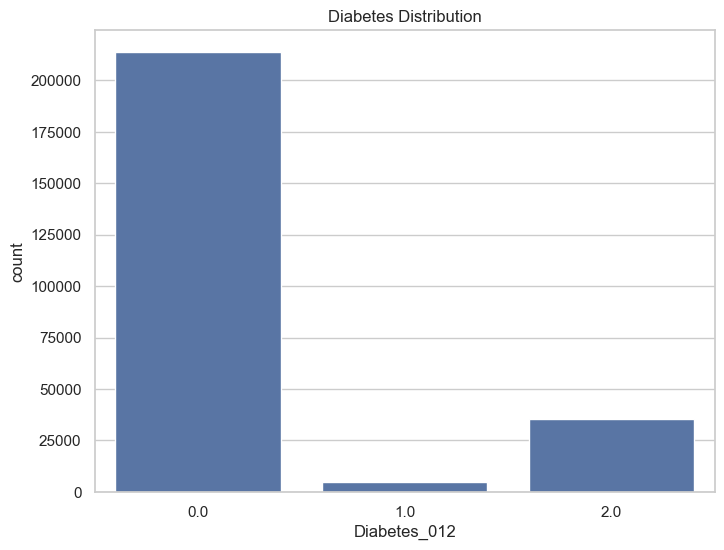

In [13]:
sns.countplot(x='Diabetes_012', data=data)
plt.title("Diabetes Distribution")
plt.show()

In [34]:
data['Diabetes_binary'] = np.where(data['Diabetes_012'] > 0, 1, 0)

In [36]:
data['Diabetes_binary'].mean()

0.15758830022075054

In [46]:
data['Diabetes_binary'].value_counts(normalize=True)

Diabetes_binary
0    0.842412
1    0.157588
Name: proportion, dtype: float64

In [47]:
data['Obesity'] = np.where(data['BMI'] >= 30, 1, 0)

In [41]:
data['PoorGenHlth'] = np.where(data['GenHlth'] >= 4, 1, 0)

In [49]:
data['FrequentMentalDistress'] = np.where(data['MentHlth'] >= 14, 1, 0)

In [50]:
data['FrequentPhysicalDistress'] = np.where(data['PhysHlth'] >= 14, 1, 0)

In [51]:
disease_cols = [
    'HighBP',
    'HighChol',
    'Stroke',
    'HeartDiseaseorAttack',
    'DiffWalk',
    'Obesity',
    'PoorGenHlth',
    'Diabetes_binary'
]

disease_df = data[disease_cols].astype(int)

In [52]:
prevalence = disease_df.mean().sort_values(ascending=False)
prevalence

HighBP                  0.429001
HighChol                0.424121
Obesity                 0.346306
PoorGenHlth             0.172071
DiffWalk                0.168224
Diabetes_binary         0.157588
HeartDiseaseorAttack    0.094186
Stroke                  0.040571
dtype: float64

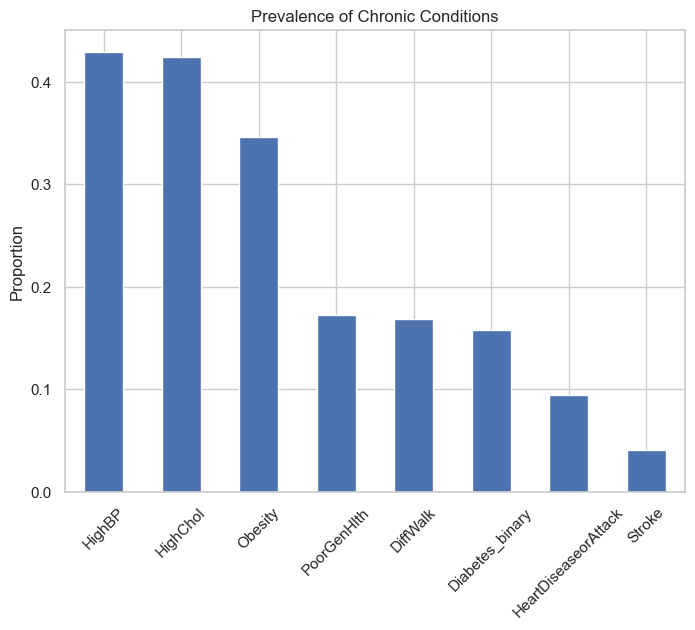

In [56]:
prevalence.plot(kind='bar')
plt.title("Prevalence of Chronic Conditions")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.show()

In [57]:
co_occurrence = disease_df.T.dot(disease_df)
co_occurrence

,HighBP,HighChol,Stroke,HeartDiseaseorAttack,DiffWalk,Obesity,PoorGenHlth,Diabetes_binary
HighBP,108829,64660,7625,17928,28810,49676,28917,29517
HighChol,64660,107591,6656,16753,24884,43046,25584,26561
Stroke,7625,6656,10292,3937,5037,4046,5010,3533
HeartDiseaseorAttack,17928,16753,3937,23893,9915,10129,10835,8542
DiffWalk,28810,24884,5037,9915,42675,22400,23655,14406
Obesity,49676,43046,4046,10129,22400,87851,21275,22945
PoorGenHlth,28917,25584,5010,10835,23655,21275,43651,15744
Diabetes_binary,29517,26561,3533,8542,14406,22945,15744,39977


In [58]:
co_occurrence['Diabetes_binary'].sort_values(ascending=False)

Diabetes_binary         39977
HighBP                  29517
HighChol                26561
Obesity                 22945
PoorGenHlth             15744
DiffWalk                14406
HeartDiseaseorAttack     8542
Stroke                   3533
Name: Diabetes_binary, dtype: int32

In [61]:
disease_df.to_csv("../data/processed/processed_disease_matrix.csv", index=False)
data.to_csv("../data/processed/processed_full_data.csv", index=False)